### 42028 : Deep Learning and CNN
### Assignment 1

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To develop SVM and Neural Network classifiers for handwritten mathematical symbol classification.
- To use Histogram Of Oriented Gradients (HoG), Local Binary Pattern (LBP), Raw images/pixels, and any other feature for classification

### Utilities

In [1]:
!pip install opencv-python --quiet

In [2]:
#Required libraries and global variables
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

#For LBP feature extraction
from skimage import feature

dataset_path = "./student_25675238/"

### Section 1 : Loading the Dataset

In [7]:
!ls

Assignment_1.ipynb  student_25675238  student_25675238.zip


In [ ]:
# !unzip student_25675238.zip # Dataset is already unzipped and extracted

In [9]:
!ls $dataset_path

 1   8	 C   N	 R  '['   b   lena.png	 metadata.json	 p   sqrt   y


*It can be observed that the dataset contains the following 10 classes of handwritten characters:*
- 1
- 8
- C
- N
- R
- '[' : Opening bracket
- b
- p
- sqrt : Square root symbol
- y

In [37]:
!find ./student_25675238/ -maxdepth 2 -type f -iname "*.jpg" -printf '%h\n' | sort | uniq -c | awk '{printf "%-25s : %s images\n", $2, $1}'

./student_25675238/1      : 500 images
./student_25675238/8      : 500 images
./student_25675238/C      : 500 images
./student_25675238/N      : 500 images
./student_25675238/R      : 500 images
./student_25675238/[      : 500 images
./student_25675238/b      : 500 images
./student_25675238/p      : 500 images
./student_25675238/sqrt   : 500 images
./student_25675238/y      : 500 images


*Each of the 10 classes consists of 500 image files in corresponding directory*

In [28]:
!find ./student_25675238/ -maxdepth 2 -type f -iname "*.jpg" | wc -l | awk '{printf "Total number of images : %s", $1}'

Total number of images : 5000

### Section 2 : Exploratory Data Analysis

*In this section, we explore the characteristics of this dataset by focussing on one category for ease of explanantion. We will use OpenCV library to access and examine the images*

*As shown in the previous sections, the dataset contains of 10 classes of hadnwritten characters which can be letters, numbers, special characters or mathematical symbols.* 

*Each class consists of 500 images, bringing the total number of images to 5000.*

In [ ]:
!pip install opencv-python

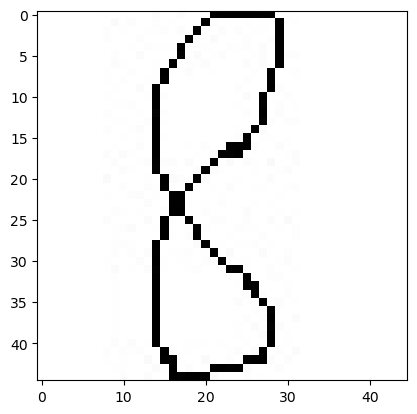

In [18]:
#Analysing sample image from class "8"

folder_path = dataset_path + "/8"
image_path = os.listdir(folder_path)
img = cv2.imread(folder_path + "/" + image_path[0])
plt.imshow(img)
plt.show()

In [12]:
#Displaying image dimensions and data types

print("Image dimensions :", img.shape)
print("Image data type :", img.dtype)
print("Image width :", img.shape[0])
print("Image length :", img.shape[1])

Image dimensions : (45, 45, 3)
Image data type : uint8
Image width : 45
Image length : 45


*The aforementioned information shows that the image is a 45X45 image with 3 channels (RGB)*

### Section 3 : Dataset Preparation

*In this section, we create a single array of all images which currently exist in separate folders.*
*This array is then divided into training, validation, and testing sets for the model*
*A similar operation is performed for creating an array of class labels, which is also divided into training, validation, and testing sets.*

In [5]:
#Listing all class folders from the main dataset folder and adding folder name to a list

class_folders = []
for f in os.listdir(dataset_path):
    if os.path.isdir(os.path.join(dataset_path, f)) and f != ".ipynb_checkpoints":
        class_folders.append(f)

print(class_folders)

['1', '8', 'C', 'N', 'R', '[', 'b', 'p', 'sqrt', 'y']


In [6]:
#Accessing each folder from class_folders list and adding the images to a list and 
#equal number of class labels to another list
#This will be the image set and label set which will be used for modelling

images = []
labels = []

for folder_name in class_folders:
    folder_path = dataset_path + "/" + folder_name
    for image in os.listdir(folder_path):
        #Verifying image file to avoid any hidden files or ipynb checkpoints
        if ".jpg" in image:
            img_array = cv2.imread(folder_path + "/" + image) #Reading images using opencv and adding to list
            images.append(img_array)
            labels.append(folder_name)
    print("All images added for label : " + folder_name)        

All images added for label : 1
All images added for label : 8
All images added for label : C
All images added for label : N
All images added for label : R
All images added for label : [
All images added for label : b
All images added for label : p
All images added for label : sqrt
All images added for label : y


In [7]:
print("Total number of images :", len(images))

Total number of images : 5000


In [8]:
print("Total number of labels :", len(labels))

Total number of labels : 5000


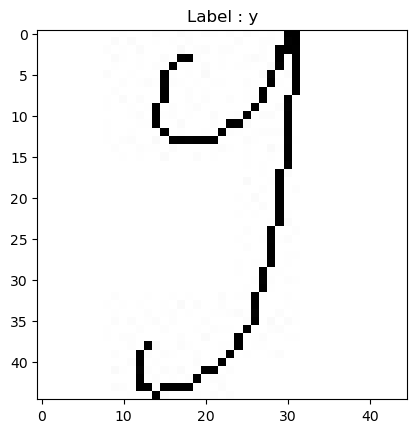

In [12]:
#Reading a random image and it's label from the lists
idx = random.randint(0, 4999)
label = labels[idx]
plt.title("Label : " + label)
plt.imshow(images[idx])
plt.show()

In [15]:
#Writing the raw images and labels to .npy files for reuse
images_np_array = np.array(images)
labels_np_array = np.array(labels)

np.save('images.npy', images_np_array)
np.save('labels.npy', labels_np_array)

### Section 4 : Image Processing 

*Converting images to grayscale. The original dataset contains images with 3 channels i.e. RGB. However, features like HOG and LBP are computed on single-channel i.e. grayscale images to reduce computational cost and loss of shape information.* 

In [3]:
#Loading images and labels from saved files
images = np.load('images.npy')
labels = np.load('labels.npy')

In [4]:
#Converting images to grayscale
gray_images = []
for img in images:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray_img)
print("Total number of Gray Images :", len(gray_images))

Total number of Gray Images : 5000


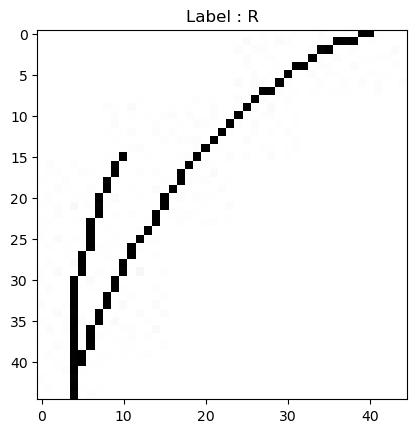

In [15]:
#Reading a random gray image and it's label from the lists
idx = random.randint(0, 4999)
label = labels[idx]
plt.title("Label : " + label)
plt.imshow(gray_images[idx], cmap='gray') # Using color map as gray for converted grayscale images
plt.show()

In [16]:
#Printing image shape
print("Image dimensions :", gray_images[idx].shape)
print("Image data type :", gray_images[idx].dtype)
print("Image width :", gray_images[idx].shape[0])
print("Image length :", gray_images[idx].shape[1])

Image dimensions : (45, 45)
Image data type : uint8
Image width : 45
Image length : 45


*It can be observed here that the image does not have the 3 channels which were present in the original dataset.*

**Note : Although, the image still appears as black and white with the colormap=gray attribute value, the change in the number of channels is the proof that this is a grayscale image**

In [3]:
#Saving grayscale images to a .npy file for reuse
gray_images_np_array = np.array(gray_images)
np.save('grayscale_images.npy', gray_images_np_array)

NameError: name 'gray_images' is not defined

*Furthermore, the image is normalized such that all values lie between a fixed range of 0-1 for simplicity of computation*

In [7]:
#Normalisation
processed_images = []
for img in gray_images:
    prc_img = img/255.0
    processed_images.append(prc_img)
print("Total number of Processed Images :", len(gray_images))

Total number of Processed Images : 5000


In [17]:
#Printing a random processed image and it's label from the lists
idx = random.randint(0, 4999)
label = labels[idx]
print("Label : " + label)
print(processed_images[idx])

Label : sqrt
[[1.         0.         0.00392157 ... 1.         1.         1.        ]
 [0.99607843 0.01176471 1.         ... 0.98823529 1.         0.99215686]
 [1.         0.         0.99215686 ... 1.         1.         0.99607843]
 ...
 [0.99215686 0.99607843 0.00784314 ... 1.         1.         1.        ]
 [1.         1.         0.99607843 ... 1.         1.         1.        ]
 [0.99607843 0.99215686 1.         ... 1.         1.         1.        ]]


*Here it is observed that the image pixels are converted to a fixed range of 0-1*

In [10]:
#Saving processed images to a .npy file for reuse
prc_images_np_array = np.array(processed_images)
np.save('processed_images.npy', prc_images_np_array)

### Section 5 : Feature Extraction (HoG, LBP, GLCM, and Gabor)

*Feature extraction is an important in any computer vision task as it transforms raw pixel data into identifiable information such as edges, texture, shapes, etc. which is required for object detection, segmentation, recognition, and classification. Feature extraction also helps in reducing the dimensionality of the image which enables the algorithms to focus on important information instead of irrelevant parts of the image.*

*In this section, the following four feature extraction techniques are used to convert the processed images from previous section into useful features*

1. Histogram of Gradients (HoG) : Represents the distribution of local gradients in form of histograms of orientation.
2. Local Binary Patterns (LBP) : LBP captures local texture information by defining a binary pattern for each pixel by comparing the intensity values of its neighbours and using a threshold to converting these intensity values to 0 or 1
3. Gray Level Co-occurrence Matrix (GLCM) : GLCM captures the spatial relationship between pixels based on their values.
4. Gabor Filters : Gabor filters are a set of linear filters tuned to different frequencies and orientations which capture the local frequency and orientation information in an image.

In [4]:
#Loading processed images from previous section
processed_images = np.load('processed_images.npy')
labels = np.load('labels.npy')

In [5]:
#Extracting features using HoG
hog_features = []
for img in processed_images:
    hog = feature.hog(
        image=img,
        orientations=8,
        pixels_per_cell=(9,9),
        cells_per_block=(3,3)
    )
    hog_features.append(hog)
print("Total number of HoG Image Features :", len(hog_features))

Total number of HoG Image Features : 5000


In [ ]:
#Displaying HoG features of a random image and it's label from the lists
idx = random.randint(0, 4999)
label = labels[idx]
plt.title("Label : " + label)
plt.imshow(hog_features[idx])
plt.show()